# Laboratorio 6 — Análisis de redes sociales de YouTube

**Repositorio:** [github.com/diegoanro22/DS-LAB06](https://github.com/diegoanro22/DS-LAB06)

Este notebook contiene la carga, integración, diagnóstico de calidad y preprocesamiento de los datos de YouTube. El análisis se mantiene en un único archivo reproducible.

In [1]:
from pathlib import Path
import ast
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
RAIZ_PROYECTO = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
ARCHIVO_VIDEOS = RAIZ_PROYECTO / 'data' / 'youtube_videos.csv'
ARCHIVO_COMENTARIOS = RAIZ_PROYECTO / 'data' / 'youtube_comments.csv'
assert ARCHIVO_VIDEOS.exists() and ARCHIVO_COMENTARIOS.exists(), 'Ejecute el notebook desde la carpeta que contiene los CSV.'

## 1. Carga y comprensión de los datos

- **`youtube_videos.csv`:** cada fila es un video; su llave primaria es `video_id`.
- **`youtube_comments.csv`:** cada fila es un comentario principal; su llave primaria es `comment_id`.
- **Relación:** `video_id` es llave foránea en comentarios y relaciona muchos comentarios con un video. Un canal publica videos (`channel_id`) y un autor de comentario se identifica con `author_channel_id`; los nombres y handles son etiquetas visibles, no identificadores estables.
- `category` clasifica el video según YouTube. `source_query` documenta cómo fue recolectado y no debe asumirse como tema definitivo.

In [2]:
videos = pd.read_csv(ARCHIVO_VIDEOS, encoding='utf-8-sig')
comentarios = pd.read_csv(ARCHIVO_COMENTARIOS, encoding='utf-8-sig')

resumen_carga = pd.DataFrame({
    'dataset': ['youtube_videos.csv', 'youtube_comments.csv'],
    'unidad_de_observacion': ['video de YouTube', 'comentario principal de YouTube'],
    'llave_primaria': ['video_id', 'comment_id'],
    'filas': [len(videos), len(comentarios)],
    'columnas': [videos.shape[1], comentarios.shape[1]]
})
display(resumen_carga)
display(Markdown('### Muestra de videos'))
display(videos.head(3))
display(Markdown('### Muestra de comentarios'))
display(comentarios.head(3))

,dataset,unidad_de_observacion,llave_primaria,filas,columnas
0,youtube_videos.csv,video de YouTube,video_id,293,20
1,youtube_comments.csv,comentario principal de YouTube,comment_id,406,17


### Muestra de videos

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluvias en Guatemala"", ""...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante este fin d...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTITUCIONAL,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y jefe del Mi...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #Gu...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol frontera sur"", ""Pemex notic...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Huachicol #G...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


### Muestra de comentarios

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_comments.csv,/@iamjimalesssa,hace 1 año,4,0,False,NaN


## 2. Diagnóstico inicial de calidad

Se revisan dimensiones, tipos, valores faltantes, duplicados, columnas constantes, valores extremos de conteos y consistencia de los identificadores. Los duplicados de texto no se eliminan automáticamente: dos usuarios pueden publicar el mismo contenido y siguen siendo observaciones distintas.

In [3]:
def perfil_calidad(nombre, df, id_cols):
    constantes = df.columns[df.nunique(dropna=False).eq(1)].tolist()
    return pd.DataFrame([{
        'dataset': nombre, 'filas': len(df), 'columnas': df.shape[1],
        'duplicados_fila': int(df.duplicated().sum()),
        'variables_constantes': ', '.join(constantes) if constantes else 'ninguna',
        **{f'{col}_nulos': int(df[col].isna().sum()) for col in id_cols},
        **{f'{col}_duplicados': int(df[col].duplicated().sum()) for col in id_cols}
    }])

diagnostico = pd.concat([
    perfil_calidad('videos', videos, ['video_id', 'channel_id']),
    perfil_calidad('comentarios', comentarios, ['comment_id', 'video_id', 'author_channel_id'])
], ignore_index=True)
display(diagnostico)

faltantes = pd.concat([
    videos.isna().sum().rename('videos'),
    comentarios.isna().sum().rename('comentarios')
], axis=1).fillna(0).astype(int)
faltantes = faltantes.loc[faltantes.sum(axis=1) > 0]
display(Markdown('### Variables con valores faltantes'))
display(faltantes)

display(Markdown('### Tipos observados'))
display(pd.DataFrame({'tipo_videos': videos.dtypes.astype(str)}))
display(pd.DataFrame({'tipo_comentarios': comentarios.dtypes.astype(str)}))

,dataset,filas,columnas,duplicados_fila,variables_constantes,video_id_nulos,channel_id_nulos,video_id_duplicados,channel_id_duplicados,comment_id_nulos,author_channel_id_nulos,comment_id_duplicados,author_channel_id_duplicados
0,videos,293,20,0,ninguna,0,0.0,0,196.0,NaN,NaN,NaN,NaN
1,comentarios,406,17,0,"is_pinned, viewer_rating",0,NaN,387,NaN,0.0,0.0,0.0,74.0


### Variables con valores faltantes

,videos,comentarios
published_time,13,0
view_count_text,13,0
description_snippet,25,0
description,26,0
viewer_rating,0,406


### Tipos observados

,tipo_videos
video_id,str
title,str
channel_name,str
channel_id,str
source_query,str
source_group,str
dataset_sources,str
channel_handle,str
published_time,str
view_count_text,str


,tipo_comentarios
video_id,str
comment_id,str
video_title,str
channel_name,str
channel_id,str
author_name,str
author_channel_id,str
text,str
source_query,str
source_group,str


In [4]:
consistencia = pd.DataFrame([
    {'relacion': 'channel_id → channel_name (videos)', 'IDs': videos.channel_id.nunique(), 'nombres_distintos_por_ID': int((videos.groupby('channel_id').channel_name.nunique() > 1).sum())},
    {'relacion': 'channel_id → channel_handle (videos)', 'IDs': videos.channel_id.nunique(), 'nombres_distintos_por_ID': int((videos.groupby('channel_id').channel_handle.nunique() > 1).sum())},
    {'relacion': 'author_channel_id → author_name', 'IDs': comentarios.author_channel_id.nunique(), 'nombres_distintos_por_ID': int((comentarios.groupby('author_channel_id').author_name.nunique() > 1).sum())},
    {'relacion': 'author_channel_id → author_handle', 'IDs': comentarios.author_channel_id.nunique(), 'nombres_distintos_por_ID': int((comentarios.groupby('author_channel_id').author_handle.nunique() > 1).sum())}
])
display(consistencia)

display(Markdown('### Variables que requieren precaución'))
display(pd.DataFrame([
    ['published_time / published_text', 'Son tiempos relativos; no se usan como fecha exacta.'],
    ['view_count_text / like_count_text', 'Son texto; se convierten a conteo numérico conservando el original.'],
    ['viewer_rating', 'Está vacío; no aporta análisis.'],
    ['is_pinned', 'Es constante; no discrimina observaciones.'],
    ['reply_count', 'Mide respuestas recibidas, no identifica autores ni aristas entre usuarios.'],
    ['source_query / source_group', 'Describen muestreo, no necesariamente el tema definitivo.']
], columns=['variable', 'tratamiento/precaución']))

,relacion,IDs,nombres_distintos_por_ID
0,channel_id → channel_name (videos),97,0
1,channel_id → channel_handle (videos),97,0
2,author_channel_id → author_name,332,0
3,author_channel_id → author_handle,332,0


### Variables que requieren precaución

,variable,tratamiento/precaución
0,published_time / published_text,Son tiempos relativos; no se usan como fecha exacta.
1,view_count_text / like_count_text,Son texto; se convierten a conteo numérico conservando el original.
2,viewer_rating,Está vacío; no aporta análisis.
3,is_pinned,Es constante; no discrimina observaciones.
4,reply_count,"Mide respuestas recibidas, no identifica autores ni aristas entre usuarios."
5,source_query / source_group,"Describen muestreo, no necesariamente el tema definitivo."


## 3. Normalización e integración

Los IDs se convierten a texto y se retiran espacios laterales, sin reemplazarlos por nombres. Se integra con una unión `many-to-one`: muchos comentarios pueden pertenecer a un único video. La validación evita una relación errónea si existieran `video_id` duplicados en la tabla de videos.

In [5]:
ID_VIDEOS = ['video_id', 'channel_id']
ID_COMENTARIOS = ['video_id', 'comment_id', 'channel_id', 'author_channel_id']
for columna in ID_VIDEOS:
    videos[columna] = videos[columna].astype('string').str.strip()
for columna in ID_COMENTARIOS:
    comentarios[columna] = comentarios[columna].astype('string').str.strip()

comentarios_integrados = comentarios.merge(
    videos, on='video_id', how='left', validate='many_to_one',
    suffixes=('_comentario', '_video'), indicator=True
)
asociados = int((comentarios_integrados['_merge'] == 'both').sum())
display(Markdown(f'**Resultado de integración:** {asociados} de {len(comentarios)} comentarios ({asociados / len(comentarios):.1%}) se asociaron con un video.'))
display(comentarios_integrados['_merge'].value_counts().rename_axis('resultado').reset_index(name='comentarios'))
comentarios_integrados = comentarios_integrados.drop(columns='_merge')

**Resultado de integración:** 406 de 406 comentarios (100.0%) se asociaron con un video.

,resultado,comentarios
0,both,406
1,left_only,0
2,right_only,0


## 4. Conversión de conteos y revisión de extremos

La función siguiente elimina etiquetas como `vistas`, espacios y separadores de miles. También admite abreviaturas `K` y `M`; valores vacíos o inválidos se convierten en faltantes. Se conserva siempre la columna textual original para auditoría.

,variable,minimo,mediana,maximo,faltantes
0,view_count_limpio,2.0,1175.0,8190449.0,0
1,like_count_limpio,1.0,2.0,405.0,189
2,reply_count,0.0,0.0,7.0,0


/tmp/ipykernel_87664/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)
/tmp/ipykernel_87664/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)
/tmp/ipykernel_87664/1105213550.py:32: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(serie.dropna(), vert=True)


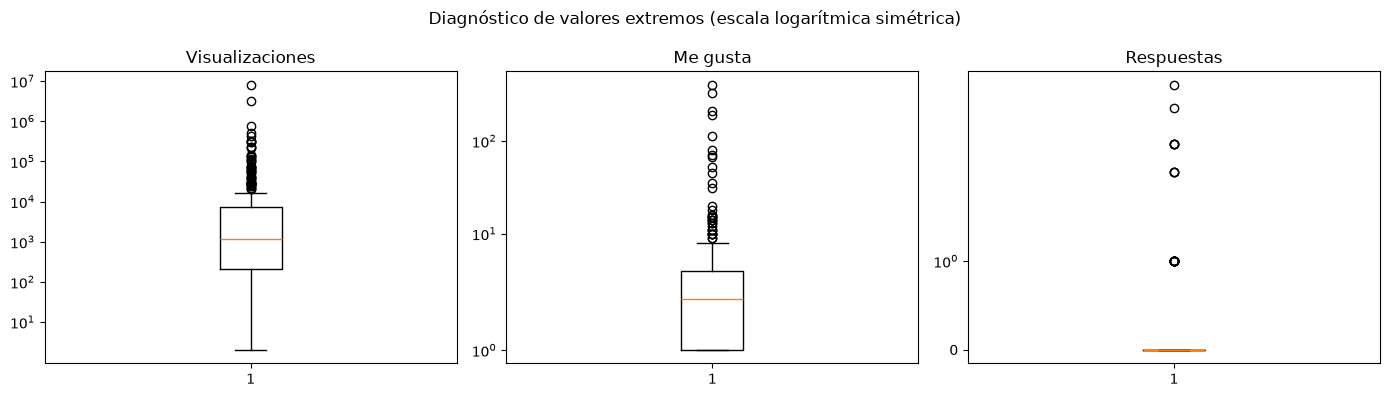

In [6]:
def convertir_conteo(valor):
    if pd.isna(valor) or not str(valor).strip():
        return np.nan
    texto = str(valor).lower().replace('vistas', '').replace('me gusta', '').strip()
    coincidencia = re.search(r'([\d.,]+)\s*([km]?)', texto)
    if not coincidencia:
        return np.nan
    numero, sufijo = coincidencia.groups()
    if re.search(r',\d{3}(?:\D|$)', numero):
        numero = numero.replace(',', '')
    else:
        numero = numero.replace(',', '.')
    try:
        return float(numero) * {'k': 1_000, 'm': 1_000_000}.get(sufijo, 1)
    except ValueError:
        return np.nan

videos['view_count_limpio'] = videos['view_count_text'].map(convertir_conteo).fillna(videos['view_count'])
comentarios['like_count_limpio'] = comentarios['like_count_text'].map(convertir_conteo)

conteos = pd.DataFrame({
    'variable': ['view_count_limpio', 'like_count_limpio', 'reply_count'],
    'minimo': [videos.view_count_limpio.min(), comentarios.like_count_limpio.min(), comentarios.reply_count.min()],
    'mediana': [videos.view_count_limpio.median(), comentarios.like_count_limpio.median(), comentarios.reply_count.median()],
    'maximo': [videos.view_count_limpio.max(), comentarios.like_count_limpio.max(), comentarios.reply_count.max()],
    'faltantes': [videos.view_count_limpio.isna().sum(), comentarios.like_count_limpio.isna().sum(), comentarios.reply_count.isna().sum()]
})
display(conteos)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, serie, titulo in zip(axes, [videos.view_count_limpio, comentarios.like_count_limpio, comentarios.reply_count], ['Visualizaciones', 'Me gusta', 'Respuestas']):
    ax.boxplot(serie.dropna(), vert=True)
    ax.set_title(titulo)
    ax.set_yscale('symlog')
plt.suptitle('Diagnóstico de valores extremos (escala logarítmica simétrica)')
plt.tight_layout()
plt.show()

## 5. Preprocesamiento de texto

`texto_original` permanece intacto para auditoría y sentimiento. `texto_limpio` se usa para frecuencias y redes temáticas: convierte a minúsculas, elimina URL y puntuación, separa hashtags/menciones para conservar sus palabras, elimina números y stopwords. Los emojis se eliminan de la versión limpia, pero se conservan en el texto original. No se lematiza en este avance porque no se carga un modelo lingüístico español externo; esta decisión queda explícita para reproducibilidad.

In [7]:
STOPWORDS_ES = {'a','al','algo','ante','antes','aqui','asi','aunque','bajo','bien','cada','casi','como','con','contra','cual','cuando','de','del','desde','donde','dos','e','el','ella','ellos','en','entre','era','es','esa','ese','eso','esta','este','esto','fue','ha','han','hasta','hay','la','las','le','les','lo','los','mas','me','mi','muy','no','nos','o','os','para','pero','poco','por','porque','que','quien','se','ser','si','sin','sobre','son','su','sus','tambien','te','tiene','todo','tu','un','una','uno','unos','ustedes','va','ya','y','yo'}

def limpiar_texto(valor):
    texto = '' if pd.isna(valor) else str(valor).lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'([#@])([\wáéíóúüñ]+)', r' \2 ', texto)
    texto = re.sub(r'[^\wáéíóúüñ\s]', ' ', texto, flags=re.IGNORECASE)
    tokens = [t for t in texto.split() if not t.isdigit() and t not in STOPWORDS_ES and len(t) > 1]
    return ' '.join(tokens)

comentarios['texto_original'] = comentarios['text'].fillna('')
comentarios['texto_limpio'] = comentarios['texto_original'].map(limpiar_texto)

efecto_limpieza = pd.DataFrame([{
    'comentarios_totales': len(comentarios),
    'textos_originales_vacios': int(comentarios.texto_original.eq('').sum()),
    'textos_limpios_vacios': int(comentarios.texto_limpio.eq('').sum()),
    'textos_modificados': int((comentarios.texto_original != comentarios.texto_limpio).sum()),
    'duplicados_texto_original': int(comentarios.texto_original.duplicated().sum()),
    'duplicados_texto_limpio': int(comentarios.texto_limpio.duplicated().sum()),
    'filas_eliminadas': 0
}])
display(efecto_limpieza)
display(comentarios[['comment_id', 'texto_original', 'texto_limpio']].head(10))

,comentarios_totales,textos_originales_vacios,textos_limpios_vacios,textos_modificados,duplicados_texto_original,duplicados_texto_limpio,filas_eliminadas
0,406,0,5,403,2,10,0


,comment_id,texto_original,texto_limpio
0,Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo vieja fiscal tengo verbose carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",están jóvenes buscan trabajo tuvieron suerte policías gusta otro vando ir vestido mujer hubieran...
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",dejaron ganas demandar ilegalidad reuniones virtuales maquila
3,Ugw0xgUc2ISpBr5_T654AaABAg,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,veremos mafioso mazariegos cárcel buen tiempo sombra
4,Ugw1ZzA21njWhaqQQTh4AaABAg,eso es para que salga de USA por su propio pie \nque se auto deporten,salga usa propio pie auto deporten
5,Ugw1ZzA21njWhaqQQTh4AaABAg.Aa9Tf29tBouAaB_XZQglTL,Imagine if they had to walk back home.,imagine if they had to walk back home
6,Ugw2014OIYf336oytFt4AaABAg,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::hand-purple-blue-peace:,buenísima investigacion hand purple blue peace hand purple blue peace hand purple blue peace
7,Ugw2bSVOoNn2pc8ZcUl4AaABAg,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están robando.",lleven lonchera sacrifiquense reintevren dinero están robando
8,Ugw3gnUvLp6AqO0_odt4AaABAg,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala
9,Ugw4C1ijI36l6LAiSZh4AaABAg,LADRONES !!!!,ladrones


## 6. Dataset integrado para análisis posterior

La siguiente tabla integra el texto procesado y los conteos limpios con la información del video. La variable se conserva en memoria como fuente para las secciones posteriores del análisis. Se verifica que el total de comentarios sea 406 y que todos estén asociados a un video.

In [8]:
comentarios_para_analisis = comentarios.merge(
    videos, on='video_id', how='left', validate='many_to_one',
    suffixes=('_comentario', '_video'), indicator=True
)
validacion_final = pd.DataFrame([{
    'comentarios_en_dataset': len(comentarios_para_analisis),
    'comentarios_asociados_a_video': int(comentarios_para_analisis['_merge'].eq('both').sum()),
    'video_id_unicos': comentarios_para_analisis.video_id.nunique(),
    'autores_unicos': comentarios_para_analisis.author_channel_id.nunique(),
    'columnas_finales': comentarios_para_analisis.shape[1]
}])
display(validacion_final)
assert len(comentarios_para_analisis) == len(comentarios)
assert comentarios_para_analisis['_merge'].eq('both').all()
comentarios_para_analisis = comentarios_para_analisis.drop(columns='_merge')
display(Markdown('El dataset integrado, los conteos limpios y las dos versiones de texto están disponibles para las secciones posteriores.'))

,comentarios_en_dataset,comentarios_asociados_a_video,video_id_unicos,autores_unicos,columnas_finales
0,406,406,19,332,41


El dataset integrado, los conteos limpios y las dos versiones de texto están disponibles para las secciones posteriores.

## 7. Análisis exploratorio y evidencia descriptiva

Esta sección describe la participación observada en la muestra. Se distinguen los 293 videos recolectados de los videos con comentarios recuperados. Un cero comentarios indica falta de cobertura en esta recolección, no ausencia comprobada de actividad en YouTube.

In [9]:
from itertools import combinations

resumen_entidades = pd.DataFrame({'entidad': ['videos', 'canales', 'comentarios', 'autores', 'videos con comentarios'], 'cantidad': [videos.video_id.nunique(), videos.channel_id.nunique(), comentarios.comment_id.nunique(), comentarios.author_channel_id.nunique(), comentarios.video_id.nunique()]})
actividad_video = comentarios_para_analisis.groupby('video_id', as_index=False).agg(comentarios=('comment_id','nunique'), autores_unicos=('author_channel_id','nunique'), likes_observados=('like_count_limpio','sum'), likes_disponibles=('like_count_limpio','count'), respuestas=('reply_count','sum'))
metricas_video = videos[['video_id','title','channel_id','channel_name','category','source_query','source_group','view_count_limpio']].merge(actividad_video, on='video_id', how='left', validate='one_to_one')
cols = ['comentarios','autores_unicos','likes_observados','likes_disponibles','respuestas']
metricas_video[cols] = metricas_video[cols].fillna(0).astype(int)
metricas_video = metricas_video.sort_values(['comentarios','view_count_limpio'], ascending=False)
metricas_canal = metricas_video.groupby(['channel_id','channel_name'], as_index=False).agg(videos=('video_id','nunique'), videos_con_comentarios=('comentarios',lambda s:int((s>0).sum())), comentarios=('comentarios','sum'), vistas_totales=('view_count_limpio','sum'), likes_observados=('likes_observados','sum'), respuestas=('respuestas','sum'))
autores_canal = comentarios_para_analisis.groupby('channel_id_video').author_channel_id.nunique()
metricas_canal['autores_unicos'] = metricas_canal.channel_id.map(autores_canal).fillna(0).astype(int)
metricas_canal = metricas_canal.sort_values(['comentarios','vistas_totales'], ascending=False)
tabla_categorias = metricas_video.groupby('category', dropna=False, as_index=False).agg(videos=('video_id','nunique'), comentarios=('comentarios','sum'), vistas=('view_count_limpio','sum'))
tabla_categorias['comentarios_por_video'] = tabla_categorias.comentarios / tabla_categorias.videos
tabla_consultas = videos.groupby('source_query', dropna=False, as_index=False).agg(videos=('video_id','nunique'), canales=('channel_id','nunique')).sort_values('videos', ascending=False)
tabla_fuentes = videos.groupby('source_group', dropna=False, as_index=False).agg(videos=('video_id','nunique'), canales=('channel_id','nunique')).sort_values('videos', ascending=False)

TOP_N = 5
concentracion = pd.DataFrame({'unidad':['top 5 videos','top 5 canales'], 'comentarios':[metricas_video.nlargest(TOP_N,'comentarios').comentarios.sum(), metricas_canal.nlargest(TOP_N,'comentarios').comentarios.sum()]})
concentracion['porcentaje'] = 100 * concentracion.comentarios / len(comentarios)

tokens = [t for x in comentarios.texto_limpio for t in x.split()]
bigramas = [f'{a} {b}' for x in comentarios.texto_limpio for a,b in zip(x.split(), x.split()[1:])]
hashtags = [h.lower() for x in comentarios.texto_original for h in re.findall(r'#([\wáéíóúüñ]+)', str(x), flags=re.I)]
def frecuencias(xs, col, n=20): return pd.DataFrame(Counter(xs).most_common(n), columns=[col,'frecuencia'])
palabras_frecuentes, bigramas_frecuentes, hashtags_frecuentes = frecuencias(tokens,'palabra'), frecuencias(bigramas,'bigrama'), frecuencias(hashtags,'hashtag')

autor_video = comentarios[['author_channel_id','video_id']].drop_duplicates()
actividad_autor = comentarios.groupby(['author_channel_id','author_name'], as_index=False).agg(comentarios=('comment_id','nunique'), videos=('video_id','nunique')).sort_values(['videos','comentarios'], ascending=False)
autores_recurrentes = actividad_autor.query('videos > 1')
pares = Counter()
for _, g in autor_video.groupby('author_channel_id'):
    for par in combinations(sorted(g.video_id.unique()), 2): pares[par] += 1
audiencias_compartidas = pd.DataFrame([(a,b,n) for (a,b),n in pares.items()], columns=['video_id_1','video_id_2','autores_compartidos']).sort_values('autores_compartidos', ascending=False) if pares else pd.DataFrame(columns=['video_id_1','video_id_2','autores_compartidos'])

correlacion_total = metricas_video[['view_count_limpio','comentarios']].rank().corr().iloc[0,1]
activos = metricas_video.query('comentarios > 0')
correlacion_activos = activos[['view_count_limpio','comentarios']].rank().corr().iloc[0,1]
tabla_correlaciones = pd.DataFrame({'universo':['todos los videos','videos con comentarios'], 'n_videos':[len(metricas_video),len(activos)], 'spearman_vistas_comentarios':[correlacion_total,correlacion_activos]})

display(Markdown('### Resumen de entidades')); display(resumen_entidades)
display(Markdown('### Videos con mayor participación')); display(metricas_video.head(15))
display(Markdown('### Canales con mayor participación')); display(metricas_canal.head(15))
display(Markdown('### Categorías')); display(tabla_categorias.sort_values('comentarios_por_video', ascending=False))
display(Markdown('### Consultas y fuentes')); display(tabla_consultas.head(15)); display(tabla_fuentes)
display(Markdown('### Concentración top 5')); display(concentracion)
display(Markdown('### Palabras, bigramas y hashtags')); display(palabras_frecuentes); display(bigramas_frecuentes); display(hashtags_frecuentes if not hashtags_frecuentes.empty else pd.DataFrame({'resultado':['sin hashtags']}))
display(Markdown('### Audiencias compartidas')); display(autores_recurrentes.head(20)); display(audiencias_compartidas.head(20))
display(Markdown('### Asociación entre vistas y comentarios')); display(tabla_correlaciones)
assert metricas_video.comentarios.sum() == len(comentarios)


### Resumen de entidades

,entidad,cantidad
0,videos,293
1,canales,97
2,comentarios,406
3,autores,332
4,videos con comentarios,19


### Videos con mayor participación

,video_id,title,channel_id,channel_name,category,source_query,source_group,view_count_limpio,comentarios,autores_unicos,likes_observados,likes_disponibles,respuestas
246,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,Quorum GT,topic,11775.0,161,128,358,101,3
229,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,@quorumgt,topic,10156.0,50,49,91,23,0
38,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,Gobierno de la República de Guatemala,topic,11670.0,45,32,90,26,11
239,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,News & Politics,Municipalidad de Guatemala,topic,304089.0,25,25,1697,23,16
130,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,News & Politics,guatemala noticias,topic,14200.0,25,18,25,11,13
136,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,@GobiernodeGuatemala,topic,3628.0,25,19,20,13,4
289,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,@quorumgt/videos,channel,1954.0,16,16,13,5,0
4,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,News & Politics,guatemala noticias,topic,6692.0,14,13,12,5,1
250,ndAZjHqzzT8,Internet: escoger el menos malo,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,@quorumgt/videos,channel,717.0,12,10,3,2,1
197,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,News & Politics,guatemala noticias,topic,5469.0,7,7,1,1,1


### Canales con mayor participación

...

### Audiencias compartidas

,author_channel_id,author_name,comentarios,videos
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2
325,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2
207,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2
211,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2


,video_id_1,video_id_2,autores_compartidos
1,ndAZjHqzzT8,yLZS3JiEBg8,2
4,j43HgwYFKfk,n8iP75gIpmw,2
0,PjmxCj-a9Hg,n8iP75gIpmw,1
2,is3Mk5oC19g,j43HgwYFKfk,1
3,06mFNPU0aB8,6W4u8sGEnGM,1
5,j43HgwYFKfk,ndAZjHqzzT8,1
6,n8iP75gIpmw,ndAZjHqzzT8,1
7,b_Hkrkl3adA,n8iP75gIpmw,1
8,WIUZtitfLRw,ndAZjHqzzT8,1
9,WIUZtitfLRw,yLZS3JiEBg8,1


### Asociación entre vistas y comentarios

,universo,n_videos,spearman_vistas_comentarios
0,todos los videos,293,0.080323
1,videos con comentarios,19,0.811497


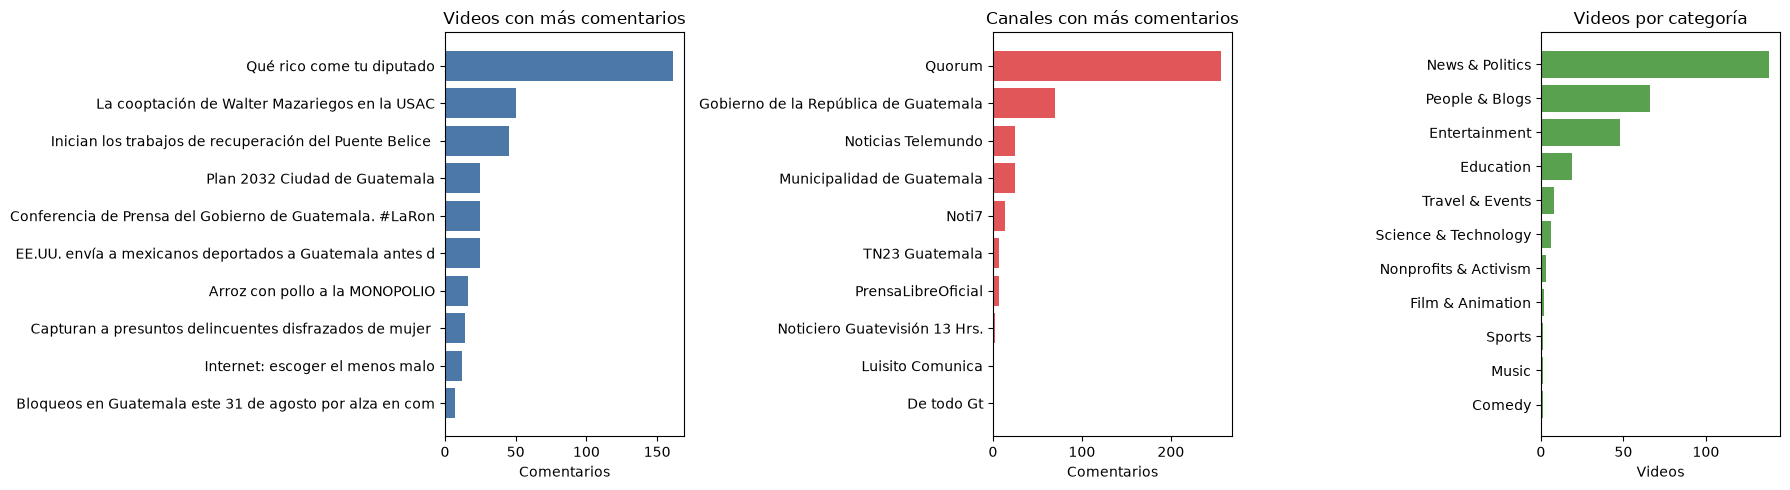

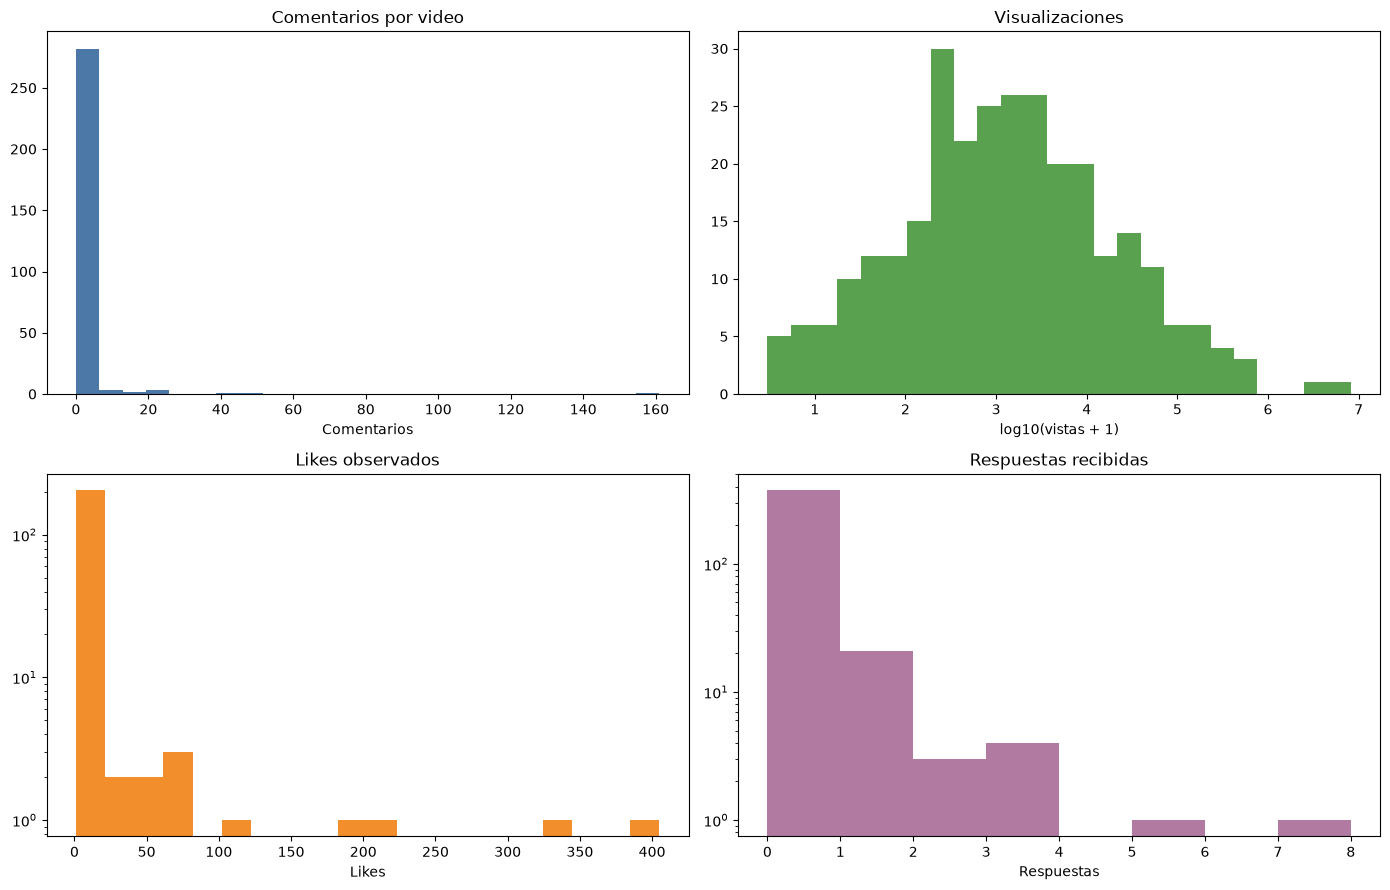

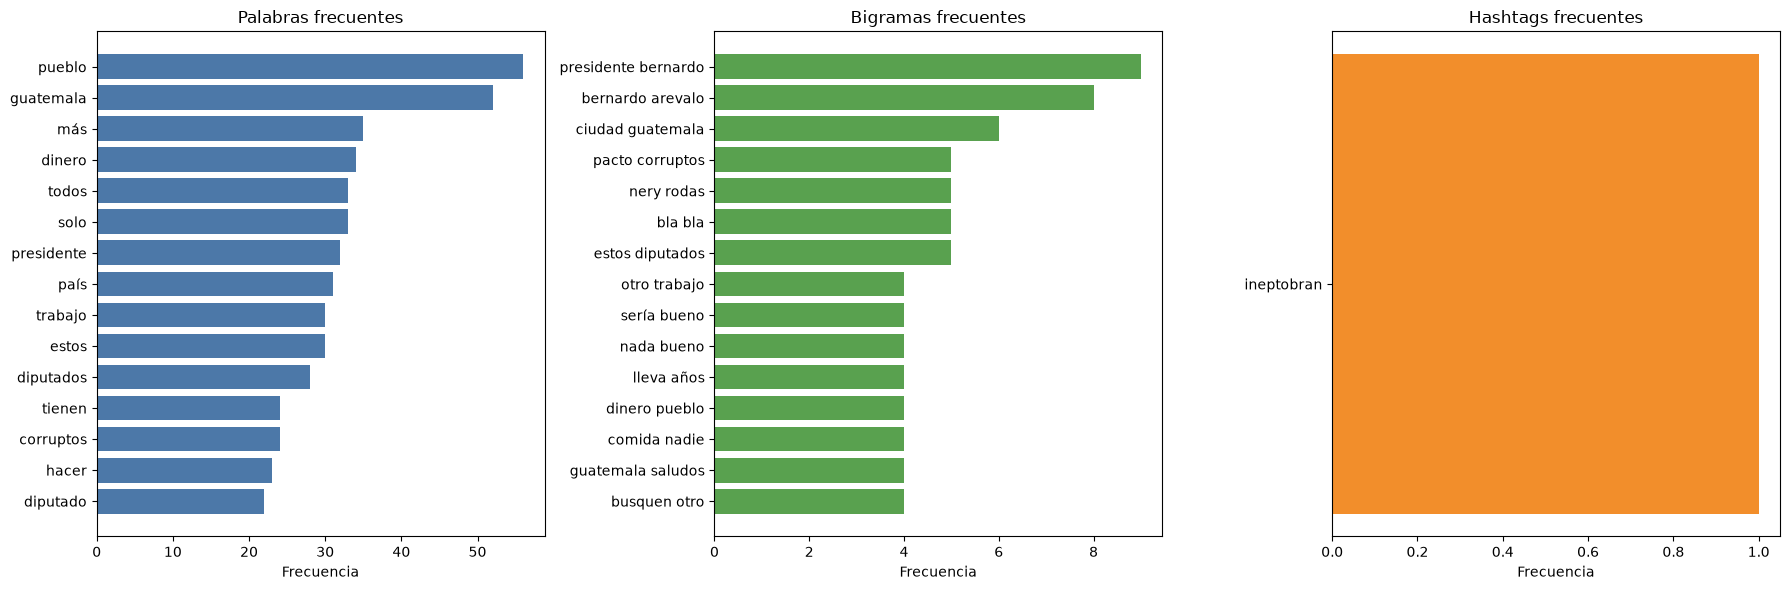

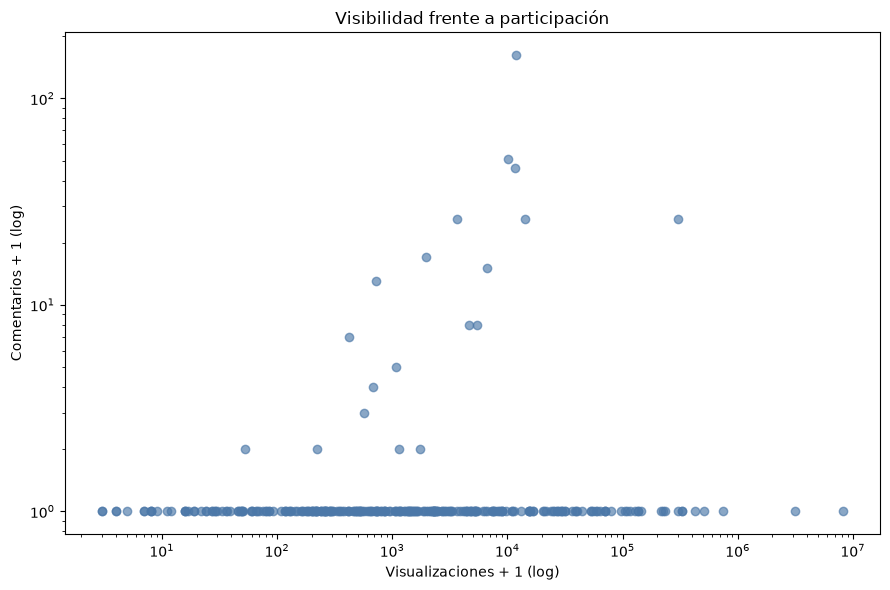

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
x = metricas_video.head(10).sort_values('comentarios'); ax[0].barh(x.title.str[:55], x.comentarios, color='#4C78A8'); ax[0].set(title='Videos con más comentarios', xlabel='Comentarios')
x = metricas_canal.head(10).sort_values('comentarios'); ax[1].barh(x.channel_name, x.comentarios, color='#E15759'); ax[1].set(title='Canales con más comentarios', xlabel='Comentarios')
x = tabla_categorias.sort_values('videos'); ax[2].barh(x.category.fillna('Sin categoría'), x.videos, color='#59A14F'); ax[2].set(title='Videos por categoría', xlabel='Videos')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax[0,0].hist(metricas_video.comentarios, bins=25, color='#4C78A8'); ax[0,0].set(title='Comentarios por video', xlabel='Comentarios')
ax[0,1].hist(np.log10(metricas_video.view_count_limpio+1), bins=25, color='#59A14F'); ax[0,1].set(title='Visualizaciones', xlabel='log10(vistas + 1)')
ax[1,0].hist(comentarios.like_count_limpio.dropna(), bins=20, color='#F28E2B'); ax[1,0].set_yscale('log'); ax[1,0].set(title='Likes observados', xlabel='Likes')
ax[1,1].hist(comentarios.reply_count, bins=range(int(comentarios.reply_count.max())+2), color='#B07AA1'); ax[1,1].set_yscale('log'); ax[1,1].set(title='Respuestas recibidas', xlabel='Respuestas')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, t, c, title in zip(ax, [palabras_frecuentes, bigramas_frecuentes, hashtags_frecuentes], ['#4C78A8','#59A14F','#F28E2B'], ['Palabras frecuentes','Bigramas frecuentes','Hashtags frecuentes']):
    if t.empty: a.text(.5,.5,'Sin observaciones',ha='center'); a.set_axis_off()
    else: z=t.head(15).sort_values('frecuencia'); a.barh(z.iloc[:,0],z.frecuencia,color=c); a.set(title=title,xlabel='Frecuencia')
plt.tight_layout(); plt.show()
plt.figure(figsize=(9,6)); plt.scatter(metricas_video.view_count_limpio+1, metricas_video.comentarios+1, alpha=.65, color='#4C78A8'); plt.xscale('log'); plt.yscale('log'); plt.xlabel('Visualizaciones + 1 (log)'); plt.ylabel('Comentarios + 1 (log)'); plt.title('Visibilidad frente a participación'); plt.tight_layout(); plt.show()


### 7.1 Preguntas exploratorias adicionales y limitaciones

Se comparan: (1) participación promedio por categoría, (2) vocabulario de comentarios con likes observados altos frente al resto, y (3) proporción de comentarios de autores recurrentes. Los resultados son descriptivos y están limitados por la cobertura parcial, las consultas de recolección, los conteos del momento de extracción y los valores ausentes de likes.

In [11]:
likes = comentarios.dropna(subset=['like_count_limpio']).copy(); umbral_like = likes.like_count_limpio.quantile(.75); likes['grupo'] = np.where(likes.like_count_limpio >= umbral_like, 'cuartil superior', 'resto observado')
vocabulario_likes = {g: frecuencias([t for x in d.texto_limpio for t in x.split()], 'palabra', 10) for g,d in likes.groupby('grupo')}
recurrentes = set(autores_recurrentes.author_channel_id); n_rec = int(comentarios.author_channel_id.isin(recurrentes).sum())
resumen_preguntas = pd.DataFrame({'indicador':['categoría con mayor comentario promedio','umbral del cuartil superior de likes observados','autores recurrentes','comentarios de autores recurrentes','porcentaje de comentarios de autores recurrentes'], 'valor':[tabla_categorias.loc[tabla_categorias.comentarios_por_video.idxmax(),'category'], umbral_like, len(recurrentes), n_rec, round(100*n_rec/len(comentarios),1)]})
display(Markdown('**Resultados de las preguntas adicionales**')); display(resumen_preguntas)
for g,t in vocabulario_likes.items(): display(Markdown(f'**Vocabulario: {g}**')); display(t)
display(Markdown(f'**Síntesis:** Los videos y canales líderes, la concentración top 5 ({concentracion.porcentaje.iloc[0]:.1f}% y {concentracion.porcentaje.iloc[1]:.1f}%), las audiencias compartidas y las correlaciones de rangos se encuentran en las tablas anteriores. La evidencia describe únicamente esta muestra: {comentarios.video_id.nunique()} de {videos.video_id.nunique()} videos tienen comentarios recuperados, por lo que no se generaliza a YouTube completo ni a Guatemala.') )


**Resultados de las preguntas adicionales**

,indicador,valor
0,categoría con mayor comentario promedio,News & Politics
1,umbral del cuartil superior de likes observados,4.0
2,autores recurrentes,9
3,comentarios de autores recurrentes,23
4,porcentaje de comentarios de autores recurrentes,5.7


**Vocabulario: cuartil superior**

,palabra,frecuencia
0,guatemala,23
1,pueblo,11
2,trabajo,8
3,ciudad,8
4,saludos,7
5,sueldo,6
6,viva,6
7,presidente,6
8,años,6
9,diputados,5


**Vocabulario: resto observado**

,palabra,frecuencia
0,pueblo,24
1,guatemala,16
2,estos,16
3,más,16
4,trabajo,15
5,presidente,13
6,país,12
7,todos,12
8,solo,11
9,dinero,10


**Síntesis:** Los videos y canales líderes, la concentración top 5 (75.4% y 96.1%), las audiencias compartidas y las correlaciones de rangos se encuentran en las tablas anteriores. La evidencia describe únicamente esta muestra: 19 de 293 videos tienen comentarios recuperados, por lo que no se generaliza a YouTube completo ni a Guatemala.

## 8. Red bipartita autor–video

La red es no dirigida y utiliza dos tipos de nodo: autores identificados por `author_channel_id` y videos identificados por `video_id`. Existe una arista cuando un autor publicó al menos un comentario en un video; su peso es la cantidad de comentarios observados de esa pareja. Los nombres y handles son solo etiquetas. La red conserva los 293 videos recolectados, incluidos aquellos sin comentarios recuperados, y la figura muestra todos los nodos y componentes.

Una conexión representa participación observada, no amistad, conversación directa ni aprobación. Los videos aislados reflejan la cobertura de esta muestra y no demuestran ausencia de actividad en YouTube.

,indicador,valor
0,comentarios_analizados,406
1,suma_pesos_aristas,406
2,pesos_equivalen_a_comentarios,True
3,autores,332
4,videos_recolectados,293
5,videos_con_arista_observada,19
6,nodos,625
7,aristas_autor_video,343
8,nodos_aislados,274
9,componentes,284


,node_id,node_type,label,author_channel_id,video_id,title,channel_name,category,view_count,has_observed_edge
0,author::UC-HeUTT6_g-VoiWds2a4H-w,author,@JorgeMunoz-gd9et,UC-HeUTT6_g-VoiWds2a4H-w,NaN,NaN,NaN,NaN,<NA>,True
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,author,@AlbertoMancilla-p9h,UC-Iul5tDYH_oiAMXQH-KaaQ,NaN,NaN,NaN,NaN,<NA>,True
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,author,@mariaalexander427,UC-QOpE7GOxlXcHZ8b7HbQKA,NaN,NaN,NaN,NaN,<NA>,True
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,author,@Tommii.10,UC-fiZBS5Gp1eCJd9ucgWnCg,NaN,NaN,NaN,NaN,<NA>,True
4,author::UC-hfX8J5JPJ-dfuakzegMLA,author,@normaleticiaorozcojuarez2418,UC-hfX8J5JPJ-dfuakzegMLA,NaN,NaN,NaN,NaN,<NA>,True


,author_channel_id,video_id,weight
0,UC2ngpd8UBQu4gcUYy0goAtg,06mFNPU0aB8,1
1,UCAxvOOHQk7dYPOajzFEVtbA,06mFNPU0aB8,2
2,UCIXLDYqR_syskKRJy_x9W9Q,06mFNPU0aB8,1
3,UCLXYp1Cvc5DLtq5UQL5D9vw,06mFNPU0aB8,1
4,UCO0zwwLWGyDgQmWPJ5Qrr1w,06mFNPU0aB8,1


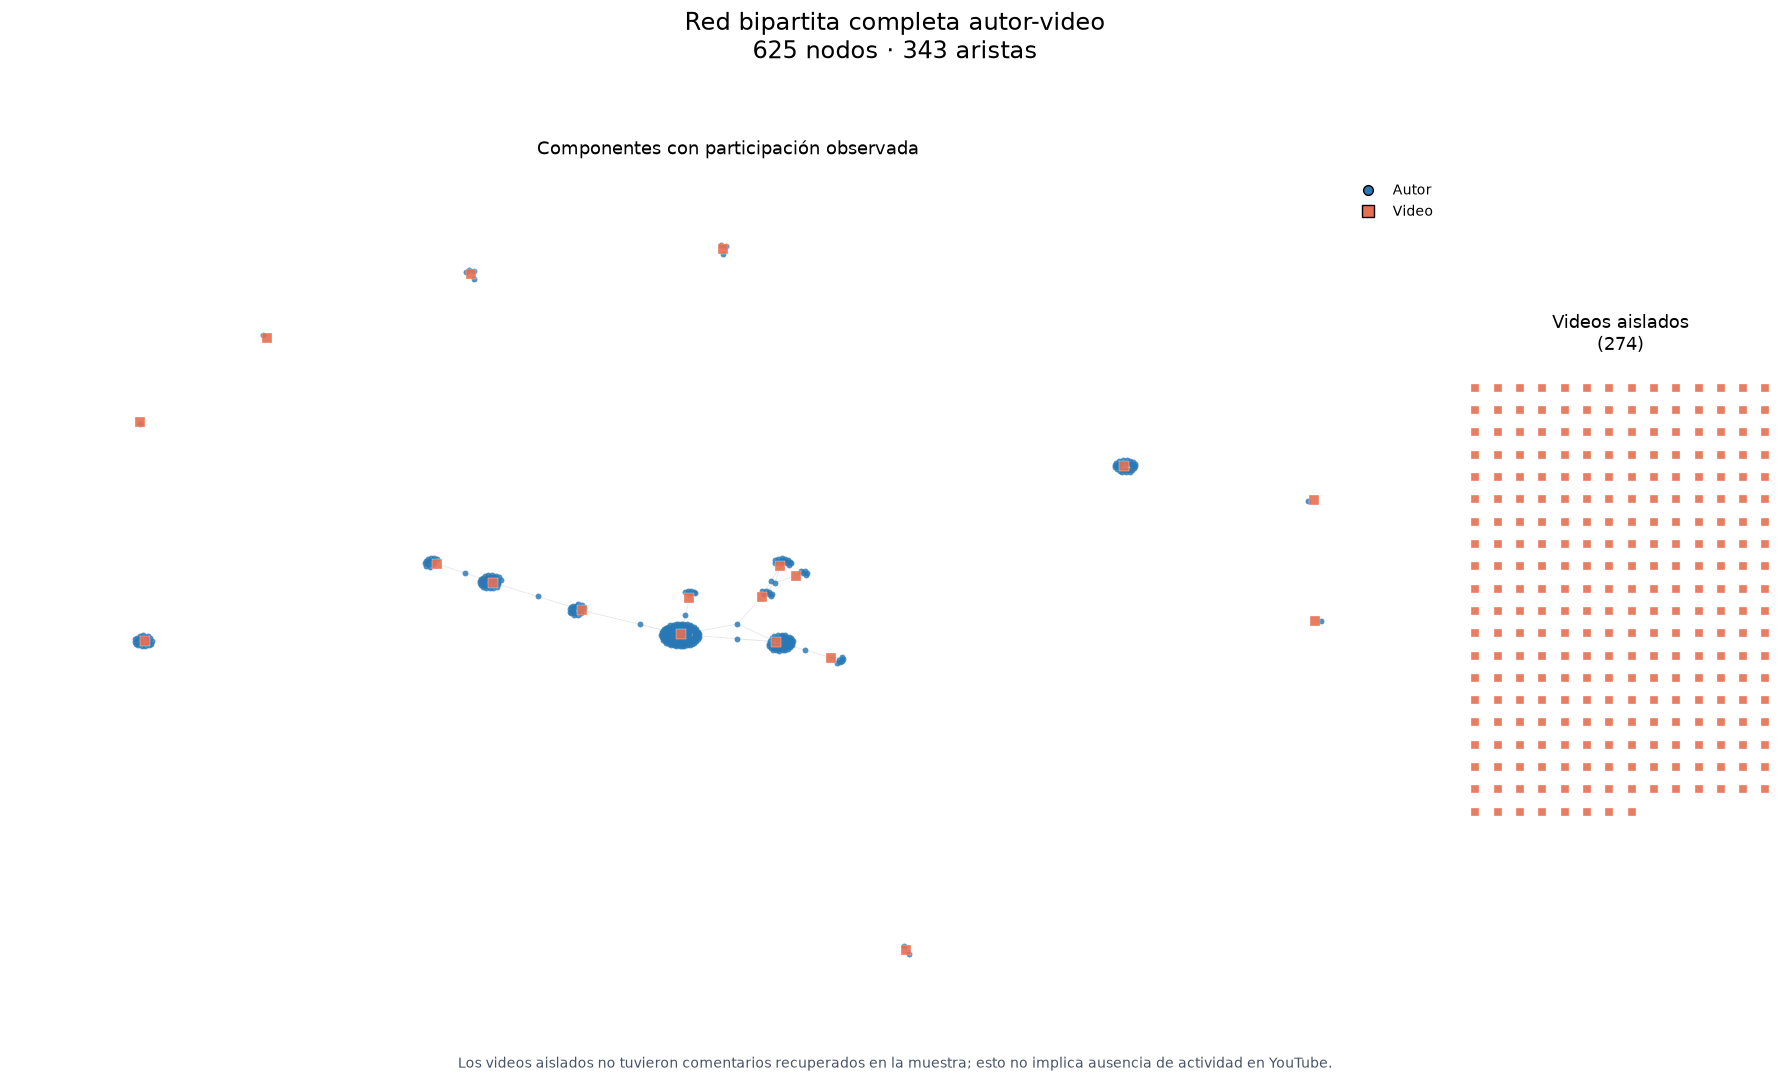

In [12]:
import sys

if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.red_bipartita import construir_red_bipartita, exportar_resultados, visualizar_red_completa

resultado_red = construir_red_bipartita(comentarios, videos)
rutas_red = exportar_resultados(resultado_red, RAIZ_PROYECTO / 'resultados')
display(resultado_red.validacion)
display(resultado_red.nodos.head())
display(resultado_red.aristas.head())

assert resultado_red.aristas['weight'].sum() == len(comentarios)
figura_red, _ = visualizar_red_completa(resultado_red.red)
plt.show()


## 9. Proyecciones, topología y fragmentación

La proyección **autor–autor** une autores que comentaron en un mismo video y su peso es el número de videos distintos compartidos. La proyección **video–video** une videos que recibieron comentarios de al menos un mismo autor y su peso es el número de autores distintos compartidos. Un comentario repetido no aumenta esos pesos.

Se conservan todos los nodos de ambas particiones: que un video esté aislado significa únicamente que no hubo comentarios o co-participación recuperados en esta muestra. Las métricas de densidad, grado y transitividad se calculan sobre la estructura no ponderada; los pesos se conservan para describir intensidad y para el diseño de las figuras. La cohesión es conectividad nodal global; en una red fragmentada vale cero por definición.

,red,tipo_de_red,nodos,aristas,densidad,grado_medio,grado_medio_ponderado,grado_maximo,componentes,tamano_componente_mayor,proporcion_componente_mayor,aislados,perifericos_grado_1,cohesion_conectividad_nodal,cohesion_componente_mayor,transitividad
0,bipartita_autor_video,bipartita_no_dirigida,625,343,0.001759,1.097600,1.299200,128,284,286,0.457600,274,327,0,1,0.000000
1,proyeccion_autor_autor,proyeccion_no_dirigida,332,10732,0.195319,64.650602,64.662651,183,10,276,0.831325,4,2,0,1,0.984025
2,proyeccion_video_video,proyeccion_no_dirigida,293,11,0.000257,0.075085,0.088737,4,284,10,0.034130,283,3,0,1,0.315789


,indicador,valor
0,autores_conservados,True
1,videos_conservados,True
2,aristas_autor_autor,10732
3,aristas_video_video,11
4,pesos_autor_autor_positivos,True
5,pesos_video_video_positivos,True


,red,grado,nodos,proporcion_nodos,grado_ponderado_medio
0,bipartita_autor_video,0,274,0.438400,0.000000
1,bipartita_autor_video,1,327,0.523200,1.183486
2,bipartita_autor_video,2,8,0.012800,2.250000
3,bipartita_autor_video,3,3,0.004800,3.333333
4,bipartita_autor_video,4,1,0.001600,4.000000
5,bipartita_autor_video,6,1,0.001600,6.000000
6,bipartita_autor_video,7,2,0.003200,7.000000
7,bipartita_autor_video,10,1,0.001600,12.000000
8,bipartita_autor_video,13,1,0.001600,14.000000
9,bipartita_autor_video,16,1,0.001600,16.000000


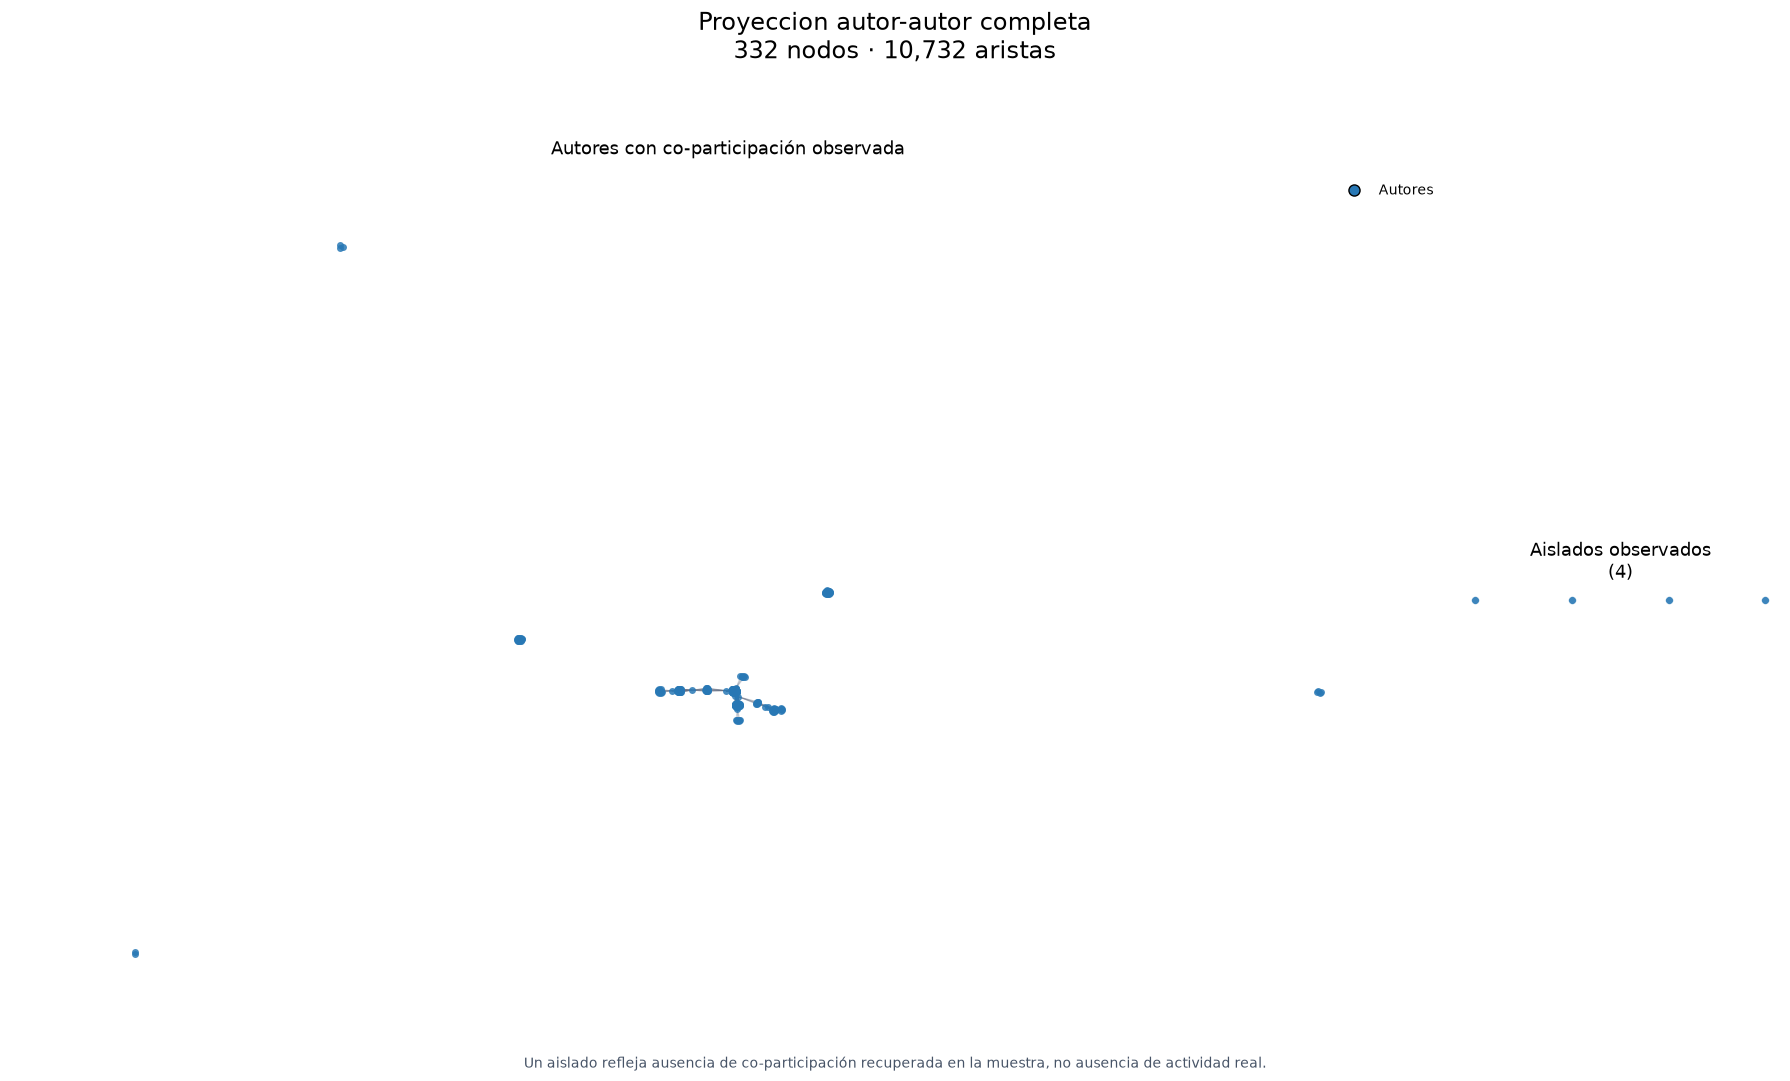

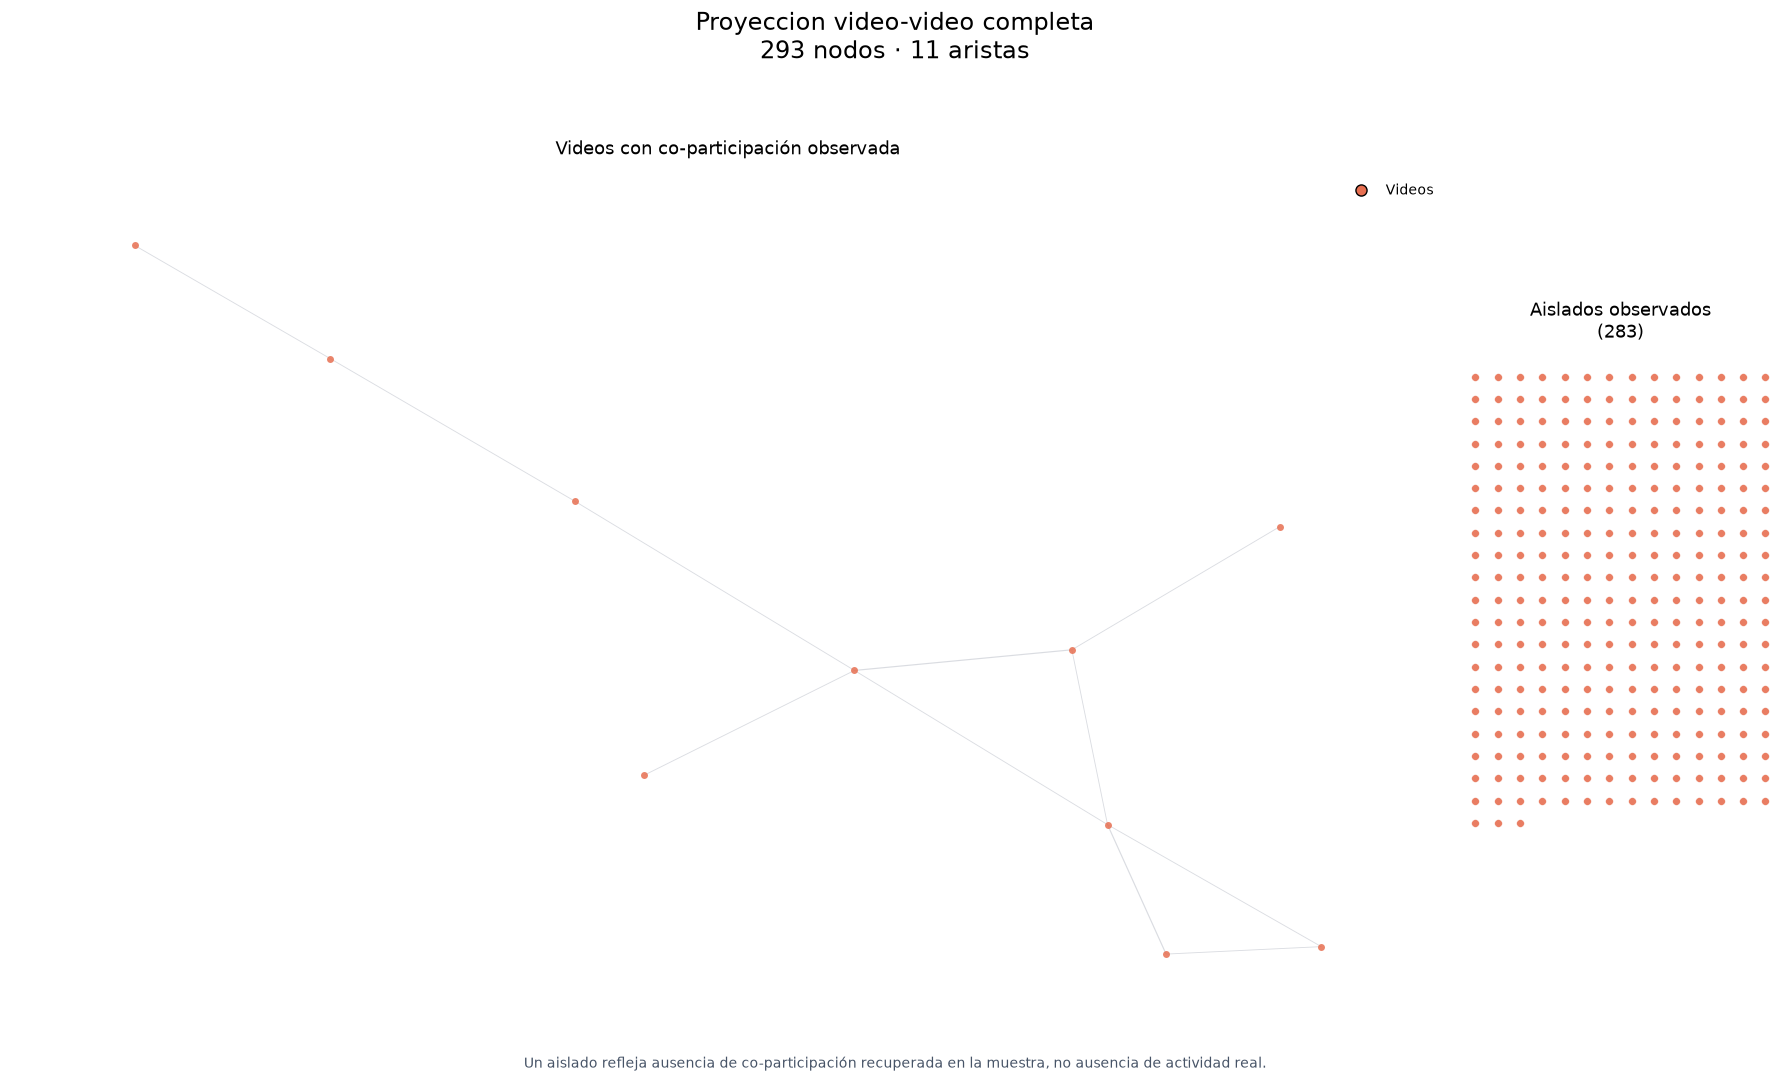

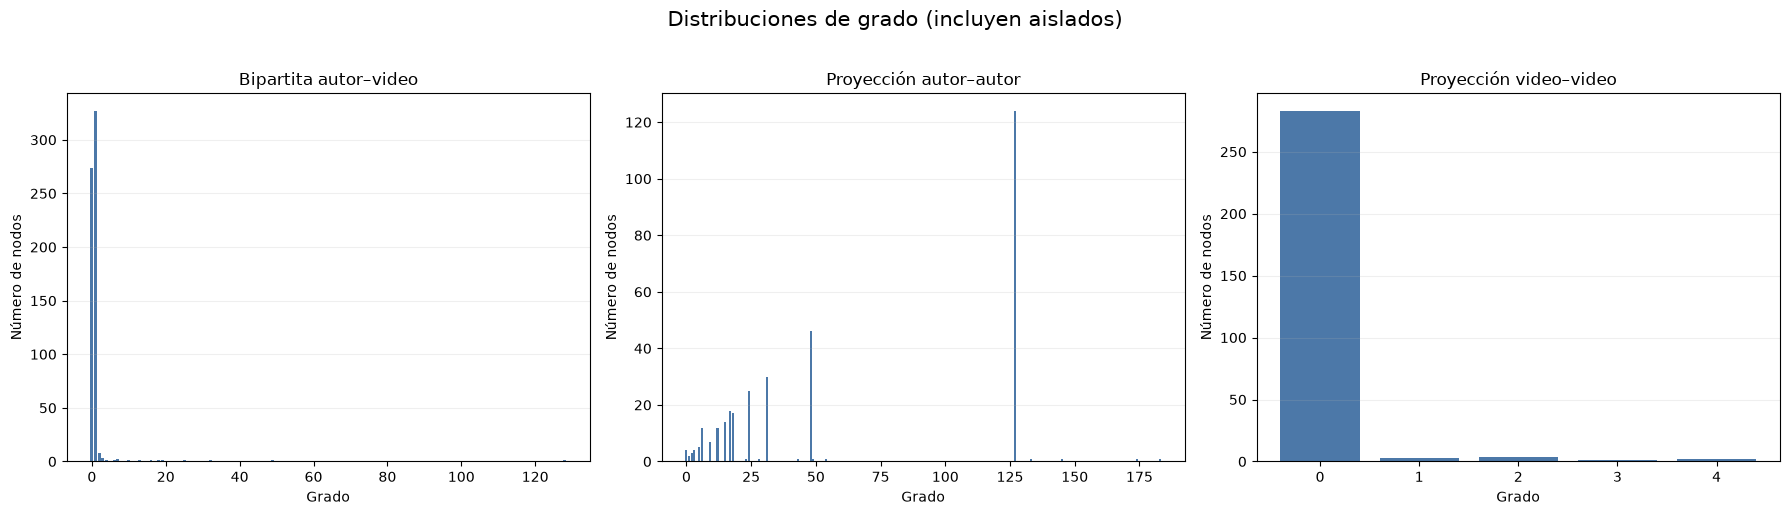

In [13]:
from src.proyecciones_topologia import (
    analizar_proyecciones, exportar_proyecciones, visualizar_distribuciones, visualizar_proyeccion,
)

resultado_proyecciones = analizar_proyecciones(resultado_red)
rutas_proyecciones = exportar_proyecciones(resultado_proyecciones, RAIZ_PROYECTO / 'resultados')
display(resultado_proyecciones.metricas)
display(resultado_proyecciones.validacion)
display(resultado_proyecciones.distribucion_grados)

assert resultado_proyecciones.validacion.loc[resultado_proyecciones.validacion.indicador == 'autores_conservados', 'valor'].iloc[0]
assert resultado_proyecciones.validacion.loc[resultado_proyecciones.validacion.indicador == 'videos_conservados', 'valor'].iloc[0]
figura_autores, _ = visualizar_proyeccion(resultado_proyecciones.autores)
plt.show()
figura_videos, _ = visualizar_proyeccion(resultado_proyecciones.videos)
plt.show()
figura_grados, _ = visualizar_distribuciones(resultado_proyecciones.distribucion_grados)
plt.show()
